In [2]:
!pip install pulp matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB 1.4 MB/s eta 0:00:10
    -------------------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import random
import csv
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMaximize, lpSum, value, LpStatus

### UTA

In [51]:
prob = LpProblem("UTA", LpMaximize)

file = csv.reader(open("Nuclear waste management.csv"))
raw_data = list(file)
data = {}
for row in raw_data[1:]:
    alt_id = row[0]
    data[alt_id] = [float(val) for val in row[1:]]

variants = [4, 6, 7, 11, 13, 14, 20, 25, 27]

G = []
for i in range(4):
    unique_vals = sorted([data[str(v)][i] for v in variants])
    G.append(unique_vals)

prob = LpProblem("True_UTA_Model", LpMaximize)
epsilon = LpVariable("epsilon", lowBound=0)
prob += epsilon, "Maximize_Epsilon"

omega = LpVariable("omega", lowBound=0.02)

u = []
for i in range(4):
    u_i = {}
    for v in variants:
        var_name = f"u_C{i+1}_{str(data[str(v)][i]).replace('.', '_')}"
        if data[str(v)][i] not in u_i:
            u_i[data[str(v)][i]] = LpVariable(var_name, lowBound=0)
    u.append(u_i)

# print("Unique values for each criterion (G_i):")
# for i, unique_vals in enumerate(G):
#     print(f"  Criterion {i+1}: {unique_vals}")

# print("\nDefined utility variables for each unique value in each criterion:")
# for i in range(4):
#     print(f"  Criterion {i+1}:")
#     for val, var in u[i].items():
#         print(f"    u({val}) -> {var.name}")

pairs = [('14', '25'), ('14', '11'), ('13', '20'), ('4', '27'), ('6', '7')]
for a, b in pairs:
    prob += lpSum([u[i][data[str(a)][i]] for i in range(4)]) - lpSum([u[i][data[str(b)][i]] for i in range(4)]) >= epsilon, f"Pref_{a}_{b}"
    # print("=" * 50)
    # print([data[str(a)][i] for i in range(4)])
    # print([data[str(b)][i] for i in range(4)])

prob += lpSum([u[i][G[i][-1]] for i in range(4)]) == 1, "Normalize_Sum_Max"
for i in range(4):
    prob += u[i][G[i][0]] == 0, f"Min_Zero_C{i+1}"

for i in range(4):
    for v1 in variants:
        for v2 in variants:
            if v1 != v2 and data[str(v1)][i] < data[str(v2)][i]:
                prob += u[i][data[str(v1)][i]] + omega <= u[i][data[str(v2)][i]], f"Monotonicity_C{i+1}_{v1}_{str(data[str(v1)][i]).replace('.', '_')}_{v2}_{str(data[str(v2)][i]).replace('.', '_')}"

prob.solve()

print(f"Solver Status: {LpStatus[prob.status]}\n")
if prob.status == 1:
    print(f"Maximized Epsilon (ε): {value(epsilon):.4f}\n")
    
    for a, b in pairs:
        u_a = sum(value(u[i][data[str(a)][i]]) for i in range(4))
        u_b = sum(value(u[i][data[str(b)][i]]) for i in range(4))
        diff = u_a - u_b
        print(f"U(a_{a}) [{u_a:.4f}] - U(a_{b}) [{u_b:.4f}] = {diff:.4f} (Valid: {diff >= value(epsilon) - 1e-6})")

    for i in range(4):
        print(f"\nPartial utility function for Criterion {i+1}:")
        for val in G[i]:
            print(f"  u({val}) = {value(u[i][val]):.4f}")
else:
    print("Model is Infeasible.")


Solver Status: Optimal

Maximized Epsilon (ε): 0.0867

U(a_14) [0.6800] - U(a_25) [0.5933] = 0.0867 (Valid: True)
U(a_14) [0.6800] - U(a_11) [0.5933] = 0.0867 (Valid: True)
U(a_13) [0.7533] - U(a_20) [0.5000] = 0.2533 (Valid: True)
U(a_4) [0.6733] - U(a_27) [0.5867] = 0.0867 (Valid: True)
U(a_6) [0.5200] - U(a_7) [0.4333] = 0.0867 (Valid: True)

Partial utility function for Criterion 1:
  u(0.34) = 0.0000
  u(0.4) = 0.0200
  u(0.48) = 0.3000
  u(0.48) = 0.3000
  u(0.61) = 0.3200
  u(0.64) = 0.3400
  u(0.69) = 0.3667
  u(0.78) = 0.3867
  u(0.8) = 0.4067

Partial utility function for Criterion 2:
  u(0.06) = 0.0000
  u(0.22) = 0.0200
  u(0.27) = 0.0533
  u(0.49) = 0.2333
  u(0.54) = 0.2533
  u(0.87) = 0.2733
  u(0.9) = 0.2933
  u(0.97) = 0.3133
  u(1.0) = 0.3333

Partial utility function for Criterion 3:
  u(0.0) = 0.0000
  u(0.0) = 0.0000
  u(0.0) = 0.0000
  u(0.38) = 0.0200
  u(0.56) = 0.0400
  u(0.71) = 0.0600
  u(0.81) = 0.0800
  u(1.0) = 0.1000
  u(1.0) = 0.1000

Partial utility fun

In [87]:
necessary_preferences = [('14', '25'), ('14', '11'), ('13', '20'), ('4', '27'), ('6', '7')]
for i in range(1, len(data.keys()) + 1):
    for j in range(1, len(data.keys()) + 1):
        if (str(i), str(j)) in pairs or (str(j), str(i)) in pairs or i == j:
            continue
        prob = LpProblem("UTAGMS", LpMaximize)
        epsilon = LpVariable("epsilon", lowBound=0)
        prob += epsilon, "Maximize_Epsilon"

        omega = LpVariable("omega", lowBound=0.00)

        _variants = variants + [i, j]
        u = []
        for k in range(4):
            u_i = {}
            for v in _variants:
                var_name = f"u_C{k+1}_{str(data[str(v)][k]).replace('.', '_')}"
                if data[str(v)][k] not in u_i:
                    u_i[data[str(v)][k]] = LpVariable(var_name, lowBound=0)
            u.append(u_i)

        _pairs = pairs + [(str(j), str(i))]
        for a, b in _pairs:
            prob += lpSum([u[k][data[str(a)][k]] for k in range(4)]) - lpSum([u[k][data[str(b)][k]] for k in range(4)]) >= epsilon, f"Pref_{a}_{b}"

        prob += lpSum([u[k][G[k][-1]] for k in range(4)]) == 1, "Normalize_Sum_Max"
        for k in range(4):
            prob += u[k][G[k][0]] == 0, f"Min_Zero_C{k+1}"

        for k in range(4):
            for v1 in variants:
                for v2 in variants:
                    if v1 != v2 and data[str(v1)][k] < data[str(v2)][k]:
                        prob += u[k][data[str(v1)][k]] + omega <= u[k][data[str(v2)][k]], f"Monotonicity_C{k+1}_{v1}_{str(data[str(v1)][k]).replace('.', '_')}_{v2}_{str(data[str(v2)][k]).replace('.', '_')}"

                prob += u[k][data[str(v1)][k]] + omega <= u[k][G[k][-1]], f"Monotonicity_C{k+1}_{v1}_max"
                prob += u[k][data[str(v1)][k]] + omega >= u[k][G[k][0]], f"Monotonicity_C{k+1}_{v1}_min"

        prob.solve()
        if prob.status == 1:
            if value(epsilon) <= 1e-6:
                necessary_preferences.append((str(i), str(j)))
        else:
            print(f"Model is Infeasible for pair ({str(i)}, {str(j)}).")

essential_pairs = necessary_preferences

In [88]:
print("\nNecessary Preferences:")
for pref in necessary_preferences:
    print(f"  {pref[0]} > {pref[1]}")


Necessary Preferences:
  14 > 25
  14 > 11
  13 > 20
  4 > 27
  6 > 7
  13 > 4
  13 > 27


In [89]:
import networkx as nx

In [90]:
def build_preference_graph(preferences):
    Gr = nx.DiGraph()
    Gr.add_edges_from(preferences)
    Gr.add_nodes_from([str(i) for i in range(1, len(data.keys()) + 1)])

    Hasse_Graph = nx.transitive_reduction(Gr)

    pos = {}
    for layer, nodes in enumerate(nx.topological_generations(Hasse_Graph)):
        x_offset = (len(nodes) - 1) / 2.0 
        for i, node in enumerate(nodes):
            pos[node] = (i - x_offset, -layer) 

    # 4. Draw the Graph
    plt.figure(figsize=(18, 12))

    nx.draw(
        Hasse_Graph, 
        pos, 
        with_labels=True, 
        node_size=2000, 
        node_color="lightblue", 
        font_size=12, 
        font_weight="bold", 
        arrows=True, 
        arrowsize=20,
        edge_color="gray"
    )

    plt.title("Hasse Diagram of Necessary Preferences (Top-Down)", fontsize=14)
    plt.show()

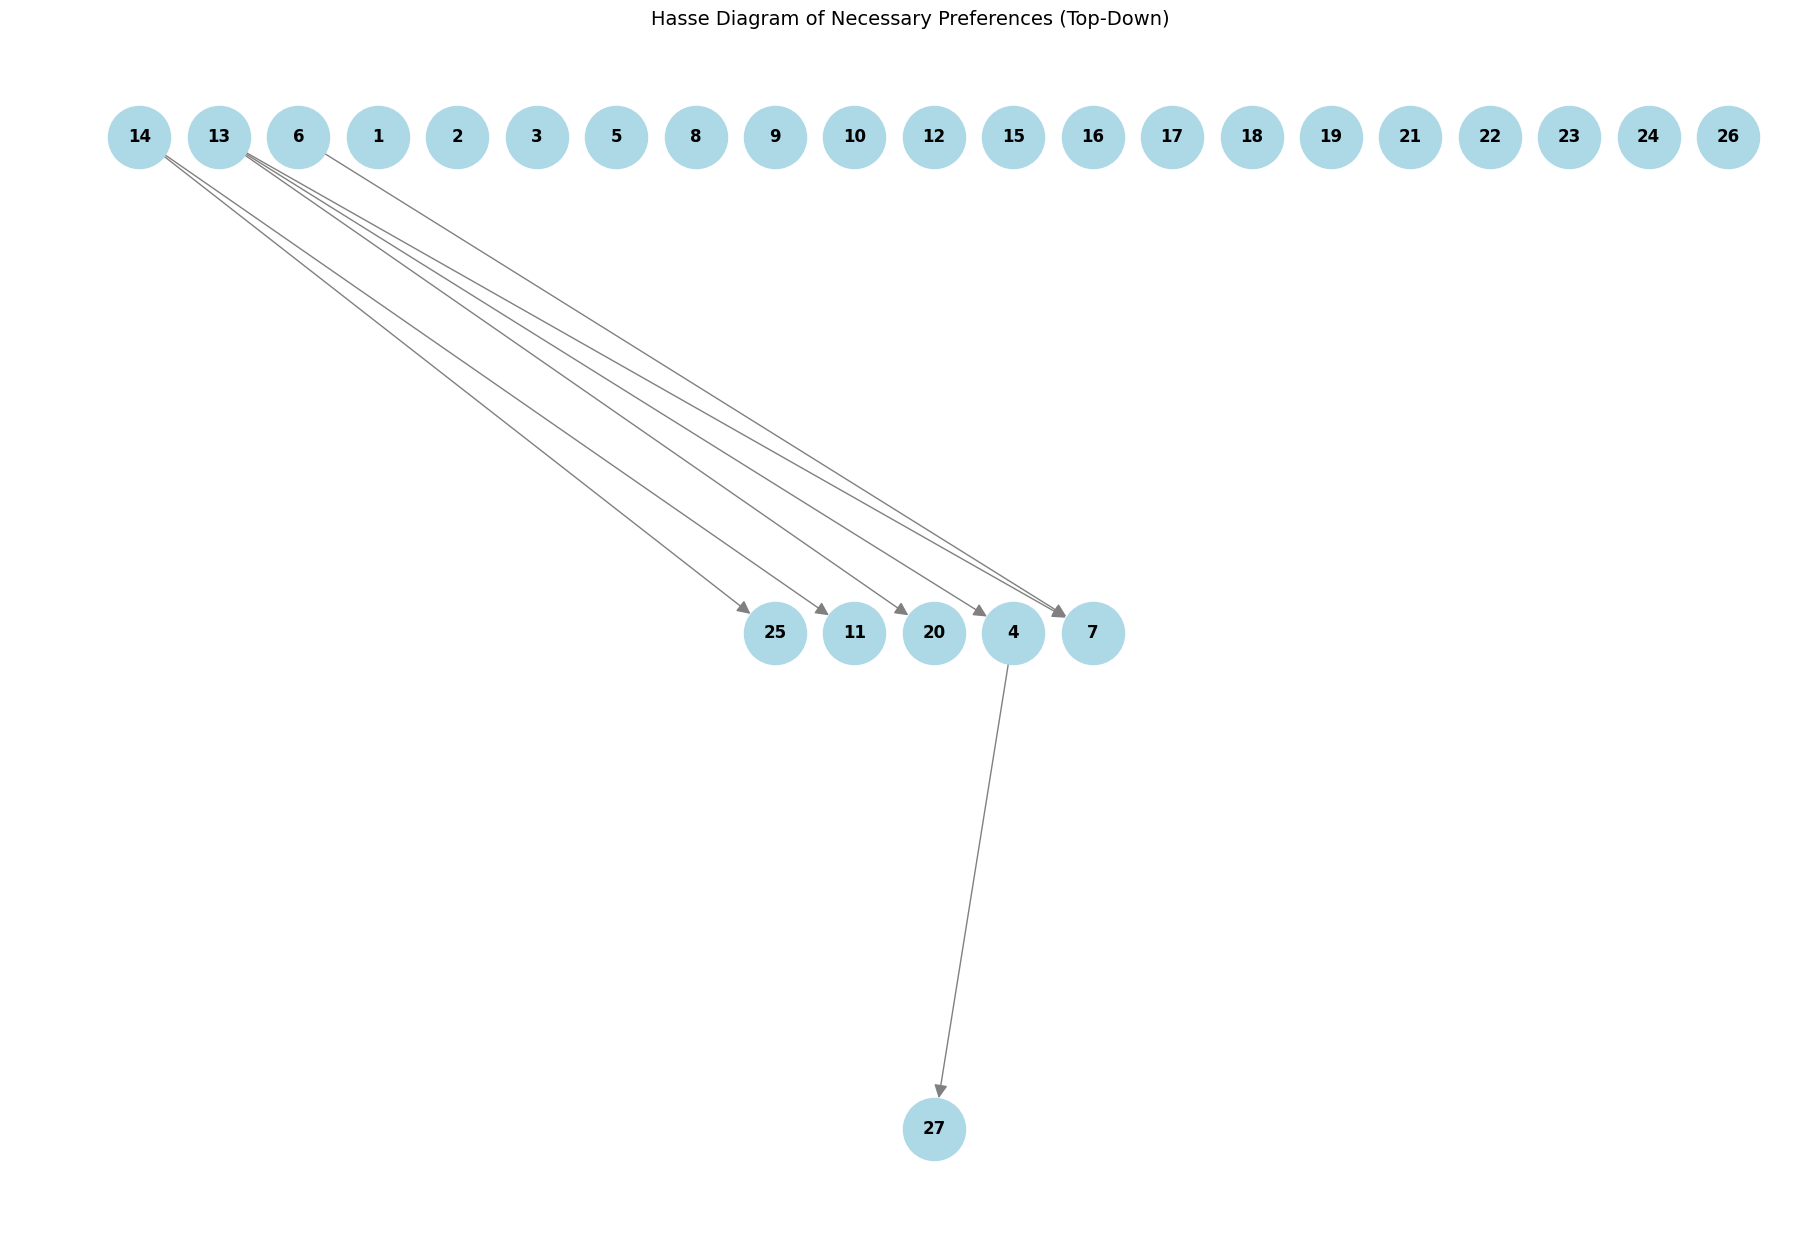

In [83]:
build_preference_graph(essential_pairs)

In [94]:
pairs = necessary_preferences.copy()
prob = LpProblem("UTAGMS", LpMaximize)
epsilon = LpVariable("epsilon", lowBound=0)
delta = LpVariable("delta", lowBound=0)
M = 1000
prob += M * epsilon - delta, "Representative_Function"

omega = LpVariable("omega", lowBound=0.00)

u = []
for k in range(4):
    u_i = {}
    for v in range(1, len(data.keys()) + 1):
        var_name = f"u_C{k+1}_{str(data[str(v)][k]).replace('.', '_')}"
        if data[str(v)][k] not in u_i:
            u_i[data[str(v)][k]] = LpVariable(var_name, lowBound=0)
    u.append(u_i)

for a, b in pairs:
    prob += lpSum([u[k][data[str(a)][k]] for k in range(4)]) - lpSum([u[k][data[str(b)][k]] for k in range(4)]) >= epsilon, f"Pref_{a}_{b}"

for i in range(1, len(data.keys()) + 1):
    for j in range(i+1, len(data.keys()) + 1):
        if (str(i), str(j)) in pairs or (str(j), str(i)) in pairs or i == j:
            continue
        prob += lpSum([u[k][data[str(i)][k]] for k in range(4)]) - lpSum([u[k][data[str(j)][k]] for k in range(4)]) <= delta, f"Indiff_{i}_{j}"
        prob += lpSum([u[k][data[str(j)][k]] for k in range(4)]) - lpSum([u[k][data[str(i)][k]] for k in range(4)]) <= delta, f"Indiff_{j}_{i}"

prob += lpSum([u[k][G[k][-1]] for k in range(4)]) == 1, "Normalize_Sum_Max"
for k in range(4):
    prob += u[k][G[k][0]] == 0, f"Min_Zero_C{k+1}"

for k in range(4):
    for v1 in variants:
        for v2 in variants:
            if v1 != v2 and data[str(v1)][k] < data[str(v2)][k]:
                prob += u[k][data[str(v1)][k]] + omega <= u[k][data[str(v2)][k]], f"Monotonicity_C{k+1}_{v1}_{str(data[str(v1)][k]).replace('.', '_')}_{v2}_{str(data[str(v2)][k]).replace('.', '_')}"

        prob += u[k][data[str(v1)][k]] + omega <= u[k][G[k][-1]], f"Monotonicity_C{k+1}_{v1}_max"
        prob += u[k][data[str(v1)][k]] + omega >= u[k][G[k][0]], f"Monotonicity_C{k+1}_{v1}_min"

prob.solve()
if prob.status == 1:
    print(f"Maximized Representative Function (M*ε - δ): {value(M * epsilon - delta):.4f}")
    for k in range(4):
        print(f"\nPartial utility function for Criterion {k+1}:")
        for i in range(1, len(data.keys()) + 1):
            val = data[str(i)][k]
            print(f"  u_{k+1}({val}) = {value(u[k][val]):.4f}")
else:
    print(f"Model is Infeasible for pair ({str(i)}, {str(j)}).")


Maximized Representative Function (M*ε - δ): 199.7000

Partial utility function for Criterion 1:
  u_1(0.6) = 0.0000
  u_1(0.66) = 0.0000
  u_1(1.0) = 0.0000
  u_1(0.48) = 0.3000
  u_1(0.62) = 0.5000
  u_1(0.78) = 0.4000
  u_1(0.4) = 0.0000
  u_1(0.64) = 0.4000
  u_1(0.65) = 0.0000
  u_1(0.45) = 0.0000
  u_1(0.61) = 0.3000
  u_1(0.74) = 0.1000
  u_1(0.48) = 0.3000
  u_1(0.69) = 0.4000
  u_1(0.87) = 0.0000
  u_1(0.44) = 0.6000
  u_1(0.68) = 0.0000
  u_1(0.76) = 0.0000
  u_1(0.35) = 0.6000
  u_1(0.64) = 0.4000
  u_1(0.83) = 0.0000
  u_1(0.32) = 0.0000
  u_1(0.59) = 0.0000
  u_1(0.73) = 0.0000
  u_1(0.34) = 0.0000
  u_1(0.71) = 0.0000
  u_1(0.8) = 0.4000

Partial utility function for Criterion 2:
  u_2(0.93) = 0.0000
  u_2(0.55) = 0.0000
  u_2(0.45) = 0.0000
  u_2(0.87) = 0.3000
  u_2(0.4) = 0.0000
  u_2(0.27) = 0.3000
  u_2(0.9) = 0.5000
  u_2(0.44) = 0.0000
  u_2(0.3) = 0.6000
  u_2(0.86) = 0.0000
  u_2(0.54) = 0.3000
  u_2(0.25) = 0.5000
  u_2(0.97) = 0.5000
  u_2(0.49) = 0.3000
  u_2(